# Module 2 — Data Exploration

Pull small samples of each data layer and print the head, just to see what the raw shapes look like before designing the real pipeline.

1. Raw scientific text — arXiv cond-mat abstracts (free API, no key)
2. Structured material records — Materials Project (needs `MP_API_KEY` env var; falls back to a tiny embedded sample if not set)
3. SFT instruction examples — templated from the structured records
4. DPO preference pairs — grounded vs hallucinated, templated from the structured records

In [1]:
import os
import json
import time
import requests
import pandas as pd
import xml.etree.ElementTree as ET

DATA_DIR = "../data"
os.makedirs(DATA_DIR, exist_ok=True)

## 1. Raw scientific text — arXiv abstracts

Query the arXiv API for `cond-mat.mtrl-sci` abstracts. No API key required.

In [2]:
def fetch_arxiv_abstracts(query="cat:cond-mat.mtrl-sci", max_results=20):
    url = "http://export.arxiv.org/api/query"
    params = {
        "search_query": query,
        "start": 0,
        "max_results": max_results,
        "sortBy": "submittedDate",
        "sortOrder": "descending",
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    ns = {"atom": "http://www.w3.org/2005/Atom"}
    root = ET.fromstring(resp.text)
    records = []
    for entry in root.findall("atom:entry", ns):
        records.append({
            "id": entry.find("atom:id", ns).text,
            "title": entry.find("atom:title", ns).text.strip().replace("\n", " "),
            "summary": entry.find("atom:summary", ns).text.strip().replace("\n", " "),
            "published": entry.find("atom:published", ns).text,
        })
    return pd.DataFrame(records)

df_text = fetch_arxiv_abstracts()
df_text.to_json(f"{DATA_DIR}/raw_text_arxiv.jsonl", orient="records", lines=True)
print(df_text.shape)
df_text.head()

(20, 4)


,id,title,summary,published
0,http://arxiv.org/abs/2606.20541v1,Controllable Quantum Spin Hall Phases in Bi$_2...,The tunability and control of topological edge...,2026-06-18T17:52:02Z
1,http://arxiv.org/abs/2606.20500v1,A Defect-Free Model of Amorphous Silicon with ...,Amorphous silicon (a-Si) is understood to be t...,2026-06-18T17:15:08Z
2,http://arxiv.org/abs/2606.20497v1,Interpretable Meta-Learning for Multi-Objectiv...,Navigating the vast space of synthetically acc...,2026-06-18T17:12:48Z
3,http://arxiv.org/abs/2606.20462v1,Polymer-polymer interdiffusion: effects of ent...,Many industrial applications and biological sc...,2026-06-18T16:44:41Z
4,http://arxiv.org/abs/2606.20412v1,Plasma Etch Process Optimization for Photonic-...,Diamond color-center qubits integrated with ph...,2026-06-18T15:59:18Z


## 1a. Token count per summary

Quick sanity check on how long each abstract is in tokens, using `tiktoken` (GPT-style BPE tokenizer) as a stand-in -- the real tokenizer will depend on the base model chosen later.

In [3]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

df_text["summary_token_count"] = df_text["summary"].apply(lambda s: len(encoding.encode(s)))
print(df_text[["title", "summary_token_count"]].to_string(index=False))
print()
print(df_text["summary_token_count"].describe())

ModuleNotFoundError: No module named 'tiktoken'

## 1b. Category paper volume

How many papers exist in each relevant arXiv category (all-time, no date filter).
Helps decide how to weight each category when building the training corpus.

In [ ]:
categories = [
    "cat:cond-mat.mtrl-sci",
    "cat:cond-mat.mes-hall",
    "cat:cond-mat.str-el",
    "cat:cond-mat.supr-con",
    "cat:physics.chem-ph",
    "cat:physics.app-ph",
]

counts = []
for cat in categories:
    resp = requests.get(
        "http://export.arxiv.org/api/query",
        params={"search_query": cat, "max_results": 1},
        timeout=30,
    )
    ns_os = {"opensearch": "http://a9.com/-/spec/opensearch/1.1/", "atom": "http://www.w3.org/2005/Atom"}
    root = ET.fromstring(resp.text)
    total = int(root.find("opensearch:totalResults", ns_os).text)
    counts.append({"category": cat.replace("cat:", ""), "total_papers": total})

df_counts = pd.DataFrame(counts).sort_values("total_papers", ascending=False)
df_counts["pct_of_total"] = (df_counts["total_papers"] / df_counts["total_papers"].sum() * 100).round(1)
print("Note: all-time counts, no date filter")
print()
print(df_counts.to_string(index=False))

Note: all-time counts, no date filter

         category  total_papers  pct_of_total
cond-mat.mtrl-sci        109904          27.9
cond-mat.mes-hall        101731          25.9
  cond-mat.str-el         83216          21.1
cond-mat.supr-con         47526          12.1
  physics.chem-ph         27487           7.0
   physics.app-ph         23663           6.0


## 1c. Category paper volume — time series (2015–2024)

Paper counts per year per category, fetched via arXiv `submittedDate` filter.
Helps understand which fields are growing and when domain activity picked up.

In [ ]:
import requests
resp = requests.get(
    "http://export.arxiv.org/api/query",
    params={"search_query": "cat:cond-mat.mtrl-sci AND submittedDate:[20200101 TO 20201231]", "max_results": 1},
    timeout=30
)
print(resp.url)
print(resp.status_code)
print(resp.text[:500])

https://export.arxiv.org/api/query?search_query=cat%3Acond-mat.mtrl-sci+AND+submittedDate%3A%5B20200101+TO+20201231%5D&max_results=1
200
<?xml version='1.0' encoding='UTF-8'?>
<feed xmlns:opensearch="http://a9.com/-/spec/opensearch/1.1/" xmlns:arxiv="http://arxiv.org/schemas/atom" xmlns="http://www.w3.org/2005/Atom">
  <id>https://arxiv.org/api/bU/1KbXXeP6Q8xODy3udV8la0QE</id>
  <title>arXiv Query: search_query=cat:cond-mat.mtrl-sci AND submittedDate:"202001010000 TO 202012312359"&amp;id_list=&amp;start=0&amp;max_results=1</title>
  <updated>2026-06-18T19:50:36Z</updated>
  <link href="https://arxiv.org/api/query?search_query=cat


In [ ]:
resp = requests.get(
    "http://export.arxiv.org/api/query?search_query=au:del_maestro+AND+submittedDate:[202301010600+TO+202401010600]&max_results=1",
    timeout=30
)
print(resp.status_code)
print(resp.text[:500])

200
<?xml version='1.0' encoding='UTF-8'?>
<feed xmlns:opensearch="http://a9.com/-/spec/opensearch/1.1/" xmlns:arxiv="http://arxiv.org/schemas/atom" xmlns="http://www.w3.org/2005/Atom">
  <id>https://arxiv.org/api/wYho3C9VqtuxCS281zH7NTkA/ys</id>
  <title>arXiv Query: search_query=au:"del maestro" AND submittedDate:"202301010600 TO 202401010600"&amp;id_list=&amp;start=0&amp;max_results=1</title>
  <updated>2026-06-18T19:50:54Z</updated>
  <link href="https://arxiv.org/api/query?search_query=au:%22de


In [ ]:
resp = requests.get(
    "http://export.arxiv.org/api/query",
    params={
        "search_query": "cat:cond-mat.mtrl-sci AND submittedDate:[202001010000 TO 202012312359]",
        "max_results": 1
    },
    timeout=30
)
root = ET.fromstring(resp.text)
ns = {"opensearch": "http://a9.com/-/spec/opensearch/1.1/"}
print("totalResults:", root.find("opensearch:totalResults", ns).text)
print(resp.url)

totalResults: 6812
https://export.arxiv.org/api/query?search_query=cat%3Acond-mat.mtrl-sci+AND+submittedDate%3A%5B202001010000+TO+202012312359%5D&max_results=1


  cond-mat.mtrl-sci 2015: 4430
  cond-mat.mtrl-sci 2016: 4433
  cond-mat.mtrl-sci 2017: 4678
  cond-mat.mtrl-sci 2018: 4933
  cond-mat.mtrl-sci 2019: 5683
  cond-mat.mtrl-sci 2020: 6812
  cond-mat.mtrl-sci 2021: 6742
  cond-mat.mtrl-sci 2022: 6505
  cond-mat.mtrl-sci 2023: 7097
  cond-mat.mtrl-sci 2024: 7611
  cond-mat.mes-hall 2015: 4980
  cond-mat.mes-hall 2016: 5229
  cond-mat.mes-hall 2017: 4991
  cond-mat.mes-hall 2018: 5260
  cond-mat.mes-hall 2019: 5685
  cond-mat.mes-hall 2020: 5846
  cond-mat.mes-hall 2021: 5375
  cond-mat.mes-hall 2022: 5060
  cond-mat.mes-hall 2023: 5461
  cond-mat.mes-hall 2024: 5694
  cond-mat.str-el 2015: 3110
  cond-mat.str-el 2016: 3306
  cond-mat.str-el 2017: 3186
  cond-mat.str-el 2018: 3532
  cond-mat.str-el 2019: 4058
  cond-mat.str-el 2020: 4125
  cond-mat.str-el 2021: 4170
  cond-mat.str-el 2022: 4072
  cond-mat.str-el 2023: 4353
  cond-mat.str-el 2024: 4359
  cond-mat.supr-con 2015: 1665
  cond-mat.supr-con 2016: 1690
  cond-mat.supr-con 2017: 16

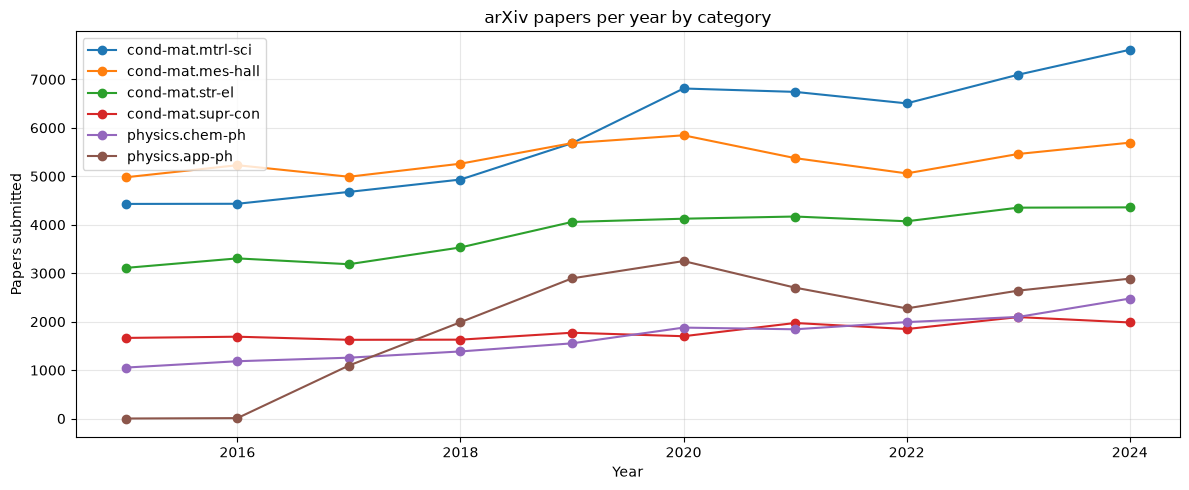

In [ ]:
import time
import matplotlib.pyplot as plt

CATEGORIES = [
    "cond-mat.mtrl-sci",
    "cond-mat.mes-hall",
    "cond-mat.str-el",
    "cond-mat.supr-con",
    "physics.chem-ph",
    "physics.app-ph",
]
YEARS = list(range(2015, 2025))

def fetch_count_for_year(category, year):
    resp = requests.get(
        "http://export.arxiv.org/api/query",
        params={
            "search_query": f"cat:{category} AND submittedDate:[{year}01010000 TO {year}12312359]",
            "max_results": 1,
        },
        timeout=30,
    )
    ns_os = {"opensearch": "http://a9.com/-/spec/opensearch/1.1/"}
    root = ET.fromstring(resp.text)
    return int(root.find("opensearch:totalResults", ns_os).text)

rows = []
for cat in CATEGORIES:
    for year in YEARS:
        count = fetch_count_for_year(cat, year)
        rows.append({"category": cat, "year": year, "papers": count})
        print(f"  {cat} {year}: {count}")
        time.sleep(3)  # arXiv rate limit

df_ts = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 5))
for cat in CATEGORIES:
    d = df_ts[df_ts["category"] == cat]
    ax.plot(d["year"], d["papers"], marker="o", label=cat)

ax.set_title("arXiv papers per year by category")
ax.set_xlabel("Year")
ax.set_ylabel("Papers submitted")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1b. Raw scientific text — full paper text

The Atom API above only returns the abstract. To see a full paper, download the PDF for one sample (the first row of `df_text`) and extract its text. Toggle `FETCH_FULL_TEXT = False` to skip this (it's slower and noisier than abstracts).

In [ ]:
FETCH_FULL_TEXT = True

def fetch_full_text(arxiv_id):
    from pypdf import PdfReader
    import io

    pdf_url = f"https://arxiv.org/pdf/{arxiv_id}"
    resp = requests.get(pdf_url, timeout=30)
    resp.raise_for_status()
    reader = PdfReader(io.BytesIO(resp.content))
    return "\n".join(page.extract_text() for page in reader.pages)

if FETCH_FULL_TEXT:
    sample_id = df_text.iloc[0]["id"].rsplit("/", 1)[-1]
    full_text = fetch_full_text(sample_id)
    with open(f"{DATA_DIR}/sample_full_paper.txt", "w") as f:
        f.write(full_text)
    print(f"arxiv id: {sample_id}")
    print(f"characters: {len(full_text)}")
    print()
    print(full_text[:-20000])

arxiv id: 2606.19254v1
characters: 163914

Spin point group symmetry and classification of non-relativistic spin splitting in
non-collinear magnetic structures: Identification of high-order spin splitting types
(ℓ=5,7, and 9)
Luis Elcoro, 1, ∗ Jesus Etxebarria, 1, † J. Manuel Perez-Mato, 2, ‡ and Emre S. Tasci 3, 4
1Department of Physics, Faculty of Science and Technology, UPV/EHU, Bilbao, Spain
2Faculty of Science and Technology, UPV/EHU, Bilbao, Spain
3Department of Physics Engineering, Hacettepe University, 06800 Ankara, Turkey
4Materials Genome Institute, Shanghai University, 200444 Shanghai, China
A comprehensive study of the possible types of non-relativistic spin splitting of electronic bands
in coplanar and non-coplanar magnetic structures is presented on the basis of spin-group theory.
As a first step, we enumerate and tabulate all possible non-equivalent spin point groups (SpPGs)
which can be expressed as a direct product of a nontrivial part and a spin-only group limited to


## 1c. Cleaning the full paper text

Instead of guessing word breaks line by line, split the paper into sections by detecting
header-shaped lines (short, ALL CAPS, e.g. `ABSTRACT`, `INTRODUCTION`, `RESULTS AND DISCUSSION`)
without hardcoding which section names to expect. Sections are kept as a plain numbered list
(not a dict), then page numbers and stray whitespace are cleaned up within each section.

In [ ]:
import re

def is_section_header(line):
    stripped = line.strip()
    letters = [ch for ch in stripped if ch.isalpha()]
    # a header-shaped line: short, mostly letters, and fully uppercase -- no assumption about which words
    return bool(letters) and len(stripped) <= 60 and stripped == stripped.upper()

def split_into_sections(text):
    lines = text.split("\n")
    sections = []
    current = []
    for line in lines:
        if is_section_header(line) and current:
            sections.append("\n".join(current))
            current = []
        current.append(line)
    if current:
        sections.append("\n".join(current))
    return sections

def clean_section(text):
    # drop standalone page-number lines, e.g. "12"
    text = re.sub(r"\n\s*\d{1,4}\s*\n", "\n", text)
    # collapse repeated blank lines and excess spaces
    text = re.sub(r"\n{2,}", "\n", text)
    text = re.sub(r" {2,}", " ", text)
    return text.strip()

if FETCH_FULL_TEXT:
    raw_sections = split_into_sections(full_text)
    cleaned_sections = [clean_section(s) for s in raw_sections]
    cleaned_text = "\n\n".join(cleaned_sections)

    with open(f"{DATA_DIR}/sample_full_paper_clean.txt", "w") as f:
        f.write(cleaned_text)

    # save just the preview snippets to separate files so before/after is easy to diff
    PREVIEW_CHARS = 1000
    with open(f"{DATA_DIR}/before_snippet.txt", "w") as f:
        f.write(full_text[:PREVIEW_CHARS])
    with open(f"{DATA_DIR}/after_snippet.txt", "w") as f:
        f.write(cleaned_text[:PREVIEW_CHARS])

    print(f"detected {len(raw_sections)} sections:")
    for i, s in enumerate(cleaned_sections, 1):
        first_line = s.strip().split("\n")[0][:60]
        print(f"  {i}. {first_line}")
    print()
    print(f"raw characters: {len(full_text)} -> cleaned characters: {len(cleaned_text)}")
    print(f"preview snippets saved to {DATA_DIR}/before_snippet.txt and {DATA_DIR}/after_snippet.txt")

detected 179 sections:
  1. Spin point group symmetry and classification of non-relativi
  2. I. INTRODUCTION
  3. PS = PNT × PSO (1)
  4. III. METHOD FOR THE SPIN-SPLITTING ANAL YSIS
  5. ∞X
  6. IV. CLASSIFICA TION OF NON-RELA TIVISTIC SPIN SPLITTINGS
  7. 141212.P 1′ (12.130.65.P1’)
  8. 161212.P 1′ (24.338.155.P1’)
  9. ℓ (ℓ = 9)
  10. 141312.P 1′ (30.559.238)
  11. (C1, C2, C3)
  12. (C1, C2, 0)
  13. (C1, C2, C3)
  14. (C1, C2, 0)
  15. ℓ (ℓ = 9)
  16. (C1, C2, C3)
  17. (C1, C2, 0)
  18. V. CONCLUSIONS
  19. ACKNOWLEDGMENTS
  20. CONTENTS
  21. S1. T ABULA TION OF THE SPIN POINT GROUPS
  22. U R
  23. {𝑚���‖2��‾ �}
  24. {𝑚���‖2���}
  25. {𝑚���‖2���}
  26. {U ′
  27. PS = PE × PSO (2)
  28. PS = {{1||1}, {4+
  29. E
  30. PE = P
  31. E × PSO (6)
  32. E
  33. PFSO = P SO
  34. E × PSOG (7)
  35. 1.1.1.P1’ 1.1.1.P 11.P 11.P1’
  36. 2.2.2.P1’ 2.2.2.P 11.P 11.P1’
  37. 2.3.3.P 21.P
  38. 2.3.4.P1’ 2.3.4.P 2100 1.P 2100 1.P1’
  39. 3.6.5.P1’ 3.6.5.P 12.P 12.P1’
  40. 3.7.6.P 22.P
 

## 2. Structured material records — Materials Project

Requires a free API key from https://materialsproject.org/api (set `MP_API_KEY` in your environment). If no key is set, falls back to a small embedded sample so the rest of the notebook still runs.

In [ ]:
MP_API_KEY = os.environ.get("MP_API_KEY")

FALLBACK_RECORDS = [
    {"material_id": "mp-149", "formula": "Si", "crystal_system": "cubic", "band_gap": 0.61, "formation_energy_per_atom": -0.51, "is_stable": True},
    {"material_id": "mp-2534", "formula": "GaAs", "crystal_system": "cubic", "band_gap": 0.19, "formation_energy_per_atom": -0.21, "is_stable": True},
    {"material_id": "mp-1265", "formula": "ZnO", "crystal_system": "hexagonal", "band_gap": 0.78, "formation_energy_per_atom": -1.5, "is_stable": True},
    {"material_id": "mp-22862", "formula": "NaCl", "crystal_system": "cubic", "band_gap": 4.85, "formation_energy_per_atom": -2.0, "is_stable": True},
    {"material_id": "mp-19017", "formula": "Fe2O3", "crystal_system": "trigonal", "band_gap": 0.0, "formation_energy_per_atom": -1.6, "is_stable": True},
]

def fetch_materials_project(limit=20):
    from mp_api.client import MPRester  # requires `pip install mp-api`
    with MPRester(MP_API_KEY) as mpr:
        docs = mpr.materials.summary.search(
            num_chunks=1, chunk_size=limit,
            fields=["material_id", "formula_pretty", "symmetry", "band_gap", "formation_energy_per_atom", "is_stable"],
        )
    records = [{
        "material_id": str(d.material_id),
        "formula": d.formula_pretty,
        "crystal_system": str(d.symmetry.crystal_system) if d.symmetry else None,
        "band_gap": d.band_gap,
        "formation_energy_per_atom": d.formation_energy_per_atom,
        "is_stable": d.is_stable,
    } for d in docs]
    return pd.DataFrame(records)

if MP_API_KEY:
    try:
        df_records = fetch_materials_project()
    except Exception as e:
        print(f"Materials Project fetch failed ({e}), using fallback sample")
        df_records = pd.DataFrame(FALLBACK_RECORDS)
else:
    print("MP_API_KEY not set, using fallback sample")
    df_records = pd.DataFrame(FALLBACK_RECORDS)

df_records.to_json(f"{DATA_DIR}/structured_records.jsonl", orient="records", lines=True)
print(df_records.shape)
df_records.head()

MP_API_KEY not set, using fallback sample
(5, 6)


,material_id,formula,crystal_system,band_gap,formation_energy_per_atom,is_stable
0,mp-149,Si,cubic,0.61,-0.51,True
1,mp-2534,GaAs,cubic,0.19,-0.21,True
2,mp-1265,ZnO,hexagonal,0.78,-1.50,True
3,mp-22862,NaCl,cubic,4.85,-2.00,True
4,mp-19017,Fe2O3,trigonal,0.00,-1.60,True


## 3. SFT instruction examples

Templated question/answer pairs generated directly from the structured records.

In [ ]:
def make_sft_examples(df):
    examples = []
    for _, r in df.iterrows():
        examples.append({
            "instruction": f"What is the band gap of {r['formula']}?",
            "response": f"{r['formula']} has a band gap of {r['band_gap']:.2f} eV, based on its {r['crystal_system']} crystal structure.",
        })
        examples.append({
            "instruction": f"Is {r['formula']} thermodynamically stable?",
            "response": f"{r['formula']} is {'stable' if r['is_stable'] else 'not stable'}, with a formation energy of {r['formation_energy_per_atom']:.2f} eV/atom.",
        })
    return pd.DataFrame(examples)

df_sft = make_sft_examples(df_records)
df_sft.to_json(f"{DATA_DIR}/sft_examples.jsonl", orient="records", lines=True)
print(df_sft.shape)
df_sft.head()

(10, 2)


,instruction,response
0,What is the band gap of Si?,"Si has a band gap of 0.61 eV, based on its cub..."
1,Is Si thermodynamically stable?,"Si is stable, with a formation energy of -0.51..."
2,What is the band gap of GaAs?,"GaAs has a band gap of 0.19 eV, based on its c..."
3,Is GaAs thermodynamically stable?,"GaAs is stable, with a formation energy of -0...."
4,What is the band gap of ZnO?,"ZnO has a band gap of 0.78 eV, based on its he..."


## 4. DPO preference pairs

Chosen = grounded in the record. Rejected = a plausible-sounding but unsupported/hallucinated claim.

In [ ]:
def make_dpo_pairs(df):
    pairs = []
    for _, r in df.iterrows():
        prompt = f"What is the band gap of {r['formula']} and is it stable?"
        chosen = (
            f"Based on the available data, {r['formula']} has a band gap of {r['band_gap']:.2f} eV "
            f"and a formation energy of {r['formation_energy_per_atom']:.2f} eV/atom, so it is "
            f"{'considered stable' if r['is_stable'] else 'not considered stable'}."
        )
        rejected = (
            f"{r['formula']} is a well-known high-performance material with an exceptionally large "
            f"band gap, making it ideal for next-generation power electronics."
        )
        pairs.append({"prompt": prompt, "chosen": chosen, "rejected": rejected})
    return pd.DataFrame(pairs)

df_dpo = make_dpo_pairs(df_records)
df_dpo.to_json(f"{DATA_DIR}/dpo_pairs.jsonl", orient="records", lines=True)
print(df_dpo.shape)
df_dpo.head()

(5, 3)


,prompt,chosen,rejected
0,What is the band gap of Si and is it stable?,"Based on the available data, Si has a band gap...",Si is a well-known high-performance material w...
1,What is the band gap of GaAs and is it stable?,"Based on the available data, GaAs has a band g...",GaAs is a well-known high-performance material...
2,What is the band gap of ZnO and is it stable?,"Based on the available data, ZnO has a band ga...",ZnO is a well-known high-performance material ...
3,What is the band gap of NaCl and is it stable?,"Based on the available data, NaCl has a band g...",NaCl is a well-known high-performance material...
4,What is the band gap of Fe2O3 and is it stable?,"Based on the available data, Fe2O3 has a band ...",Fe2O3 is a well-known high-performance materia...
